# Trabajo Práctico 3 - Minería de Datos
# Año: 2025


# Carga
---

## Librerias

In [ ]:
!pip install optuna

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns
import optuna
import random
import sklearn.metrics as metrics

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
    confusion_matrix, make_scorer)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import export_graphviz
from graphviz import Source
import warnings
warnings.filterwarnings('ignore')






## Dataset

In [ ]:
url = "https://raw.githubusercontent.com/guillericci/TP3-DataMining/refs/heads/main/dxWeather.csv"
data = pd.read_csv(url)

## Funciones

In [ ]:
def plot_multiple_conf_matrices(y_real_list, y_pred_list, titles, class_names=None):
    '''
    **Plotea múltiples matrices de confusión con nombres de clases.**

    Parámetros:
    - y_real_list : lista de arrays o Series con etiquetas reales.
    - y_pred_list: lista de arrays o Series con etiquetas predichas.
    - titles: lista de títulos para cada matriz.
    - class_names: lista opcional con nombres de clases (en orden).
    '''

    num_matrices = len(y_real_list)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()

    colormaps = ['Blues', 'Greens', 'Reds', 'Purples', 'Oranges', 'coolwarm', 'cividis', 'magma']

    for i in range(num_matrices):
        color = random.choice(colormaps)
        cm = metrics.confusion_matrix(y_real_list[i], y_pred_list[i])

        # Si no se pasan los nombres de clase, los infiere automáticamente
        labels = class_names if class_names is not None else np.unique(y_real_list[i])

        sns.heatmap(cm, annot=True, ax=axes[i], fmt='d', cmap=color,
                    xticklabels=labels, yticklabels=labels)

        axes[i].set_title(titles[i])
        axes[i].set_xlabel('Predicted labels')
        axes[i].set_ylabel('True labels')

    for j in range(num_matrices, 4):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# Analisis exploratorio
---

El dataset contiene mediciones de atributos como condiciones climaticas para la determinacion de la estacion del año

In [ ]:
data.head()

,Temperatura,Humedad,VientoVelocidad,Precipitation,PresionAtmosferica,Localizacion,TipoClima,Estacion
0,39,96,8.5,71,1011.43,Llanura,Nublado,Primavera
1,30,64,7.0,16,1018.72,Montania,Soleado,Primavera
2,38,83,1.5,82,1026.25,Costa,Soleado,Primavera
3,32,55,3.5,26,1010.03,Llanura,Nublado,Verano
4,3,85,6.0,96,984.46,Llanura,Nevado,Invierno


Visualizamos las principales medidas descriptivas de las variables numéricas.

In [ ]:
data.describe()


,Temperatura,Humedad,VientoVelocidad,Precipitation,PresionAtmosferica
count,10090.000000,10090.000000,10090.000000,10090.000000,10090.000000
mean,21.872349,67.195045,9.634936,50.796333,1007.685836
std,16.426722,20.463797,6.795890,32.333798,38.763971
min,-24.000000,20.000000,0.000000,0.000000,800.230000
25%,13.000000,55.000000,5.000000,18.000000,998.570000
50%,23.000000,69.000000,8.500000,53.000000,1010.315000
75%,32.000000,81.000000,13.500000,80.000000,1017.820000
max,109.000000,109.000000,47.500000,109.000000,1199.210000


Vemos el tipo de datos y cantidad de nulos en cada variable

In [ ]:
data.info()
data.isnull().any().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10090 entries, 0 to 10089
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Temperatura         10090 non-null  int64  
 1   Humedad             10090 non-null  int64  
 2   VientoVelocidad     10090 non-null  float64
 3   Precipitation       10090 non-null  int64  
 4   PresionAtmosferica  10090 non-null  float64
 5   Localizacion        10090 non-null  object 
 6   TipoClima           10090 non-null  object 
 7   Estacion            10090 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 630.8+ KB


np.int64(0)

Verificamos que no hay datos nulos en todo el dataset y además las variables corresponden a tipos de datos correctos.

Visualizamos la matriz correlación para observar la relación lineal de las variables numéricas.

In [ ]:
# filtrar del data solo columnas numericas
#numeric_cols = data.select_dtypes(include=[np.number])
cols = data.columns.tolist()
numeric_cols = data[cols].select_dtypes(include=[np.number])

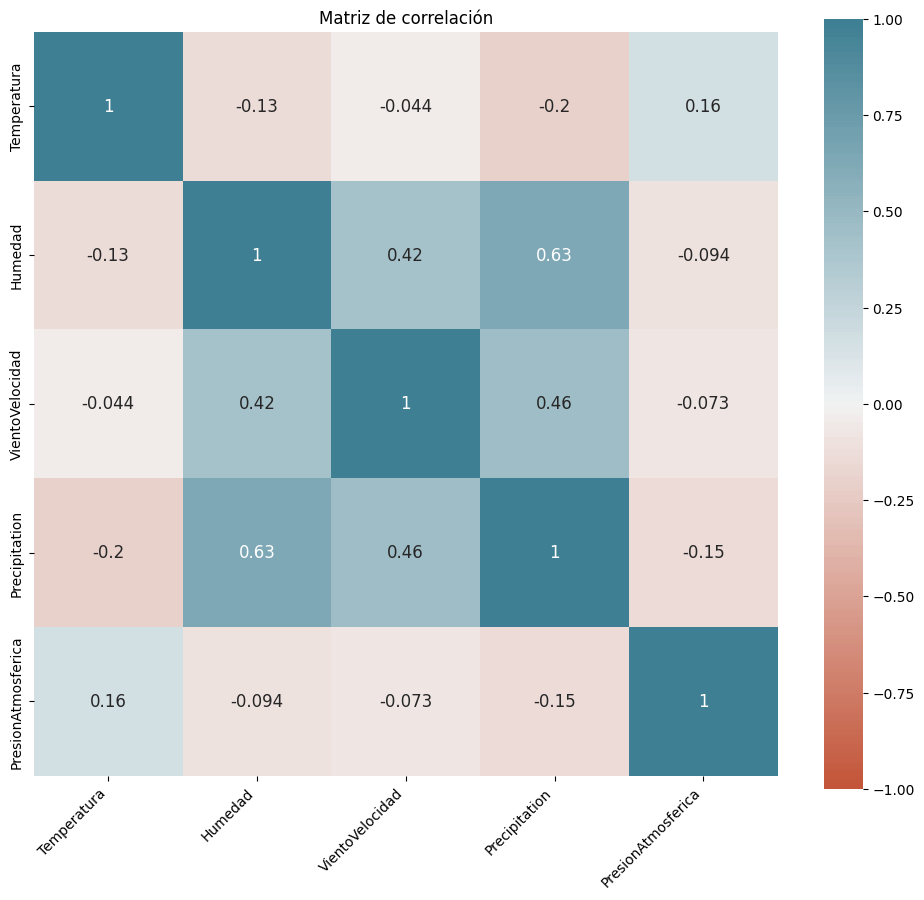

In [ ]:
# Calcular la matriz de correlación
corr = numeric_cols.corr()
# Crear una figura más grande
plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 12}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de correlación')
plt.show()

Observamos una correlación de 0.63 entre Humedad y Precipitación.

Graficamos la dispersión de las variables numéricas.



<Figure size 1200x1000 with 0 Axes>

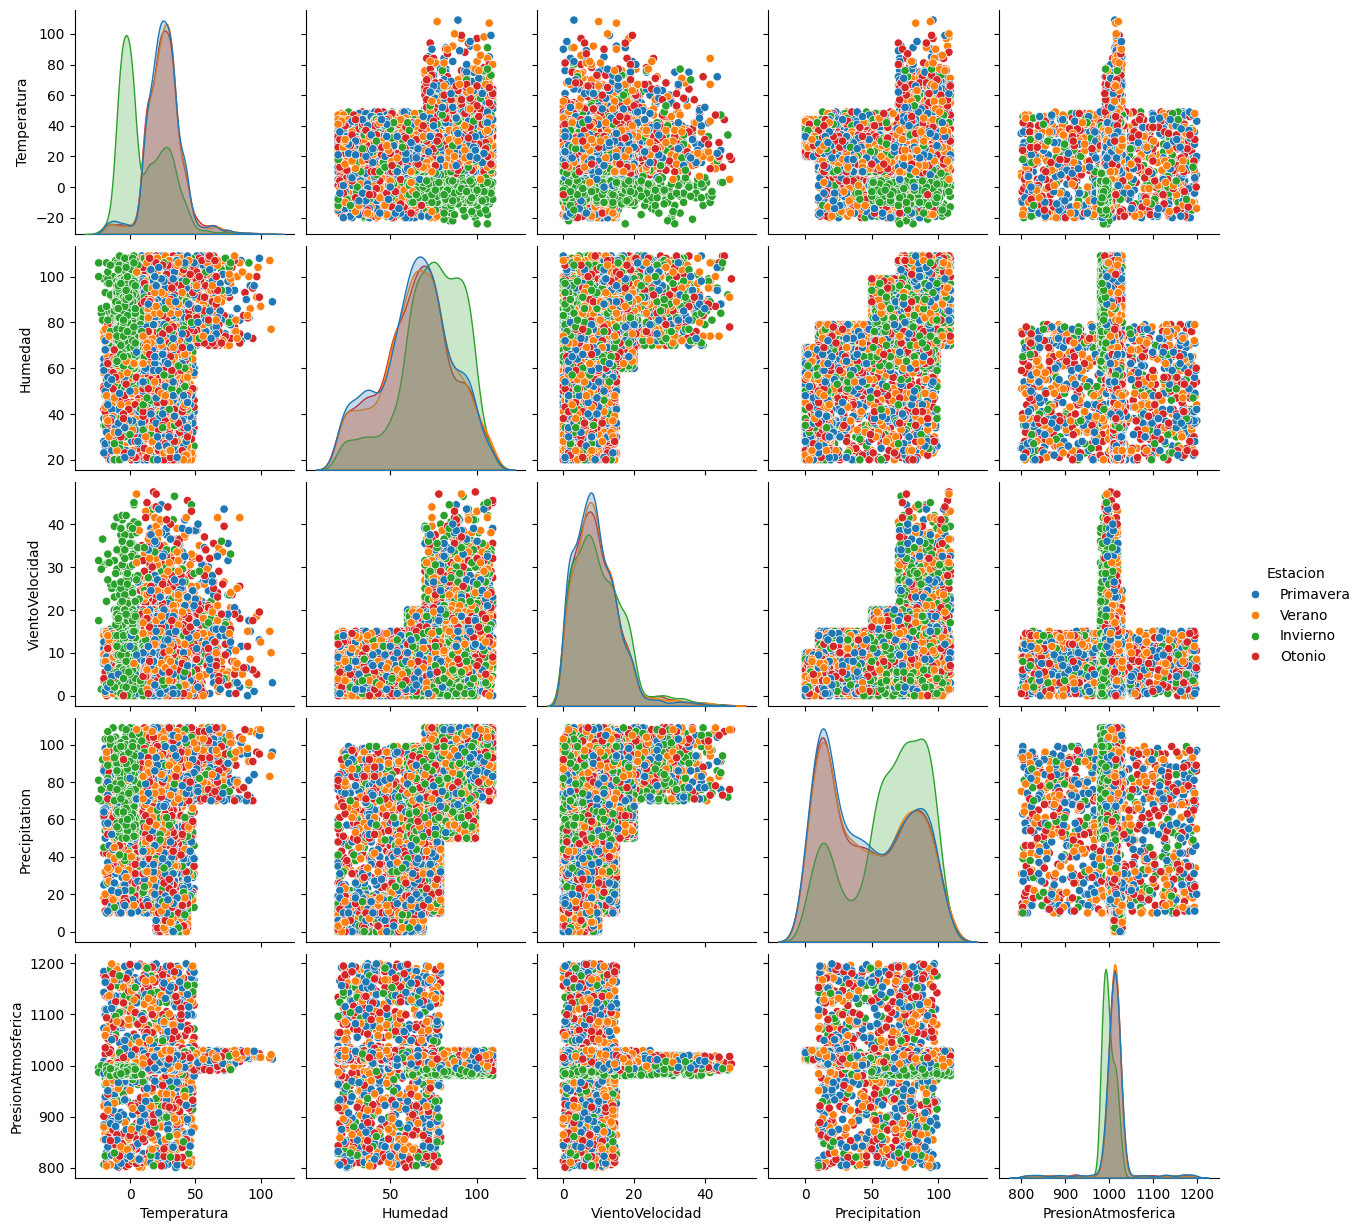

In [ ]:
cols = numeric_cols.columns.tolist() + ['Estacion']
plt.figure(figsize=(12, 10))
sns.pairplot(data[cols], hue='Estacion')
plt.show()

Podemos visualizar una concentración en temperaturas más bajas para el invierno en comparación con otras estaciones. También observamos una mayor frecuencia en precipitaciones más intensas para el invierno. No se visualizan correlaciones lineales fuertes entre las variables.

Visualizamos la distribución de las variables categóricas.

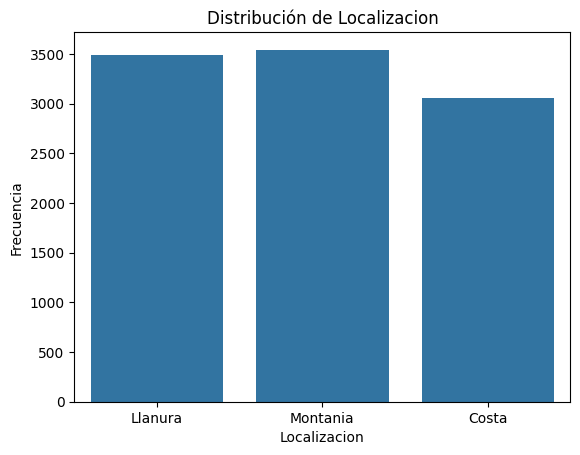

In [ ]:
sns.countplot(data=data, x='Localizacion')
plt.title('Distribución de Localizacion')
plt.xlabel('Localizacion')
plt.ylabel('Frecuencia')
plt.show()

Observamos una distribución equilibrada de las distintas localizaciones.

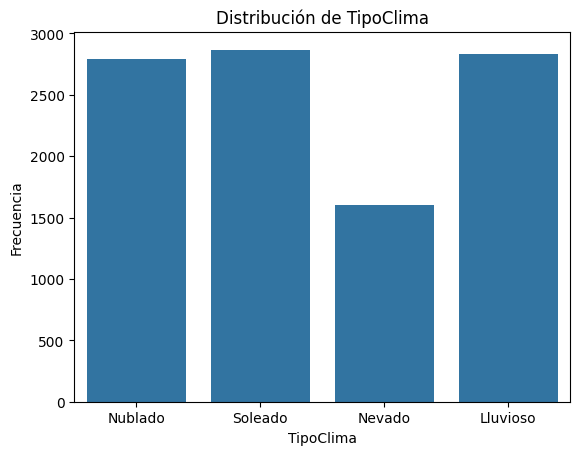

In [ ]:
sns.countplot(data=data, x='TipoClima')
plt.title('Distribución de TipoClima')
plt.xlabel('TipoClima')
plt.ylabel('Frecuencia')
plt.show()

Observamos menores registros de TipoClima 'Nevado' que del resto de las categorías.

## Visualizacion y tratamiento de Outliers

Visualizamos los boxplot de las variables numéricas.


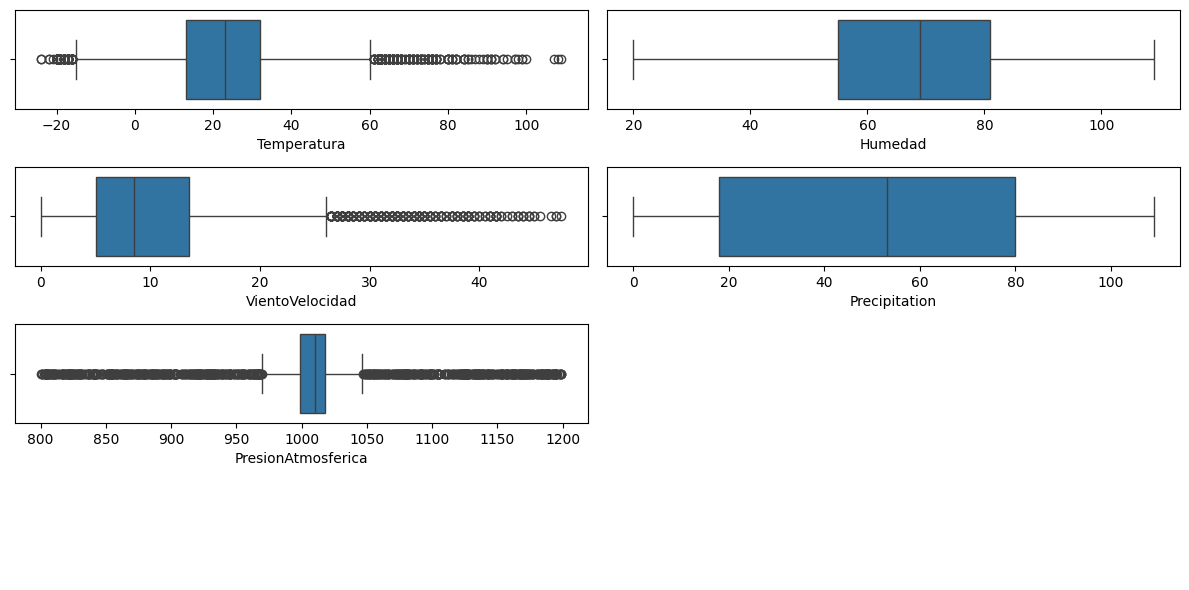

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 6))
k = 0
# Get the list of column names
numeric_col_names = numeric_cols.columns.tolist()
for i in range(0,4):
    for j in range(0,2):
      if k > len(numeric_col_names)-1:
        break
      else:
        # Seleccionar la columna correspondiente usando el nombre de la columna
        col_name = numeric_col_names[k]
        sns.boxplot(x=numeric_cols[col_name], ax=axes[i,j])
        # Incrementar el índice de la columna
        k += 1

axes[2,1].axis('off')
axes[3,1].axis('off')
axes[3,0].axis('off')
plt.tight_layout()
plt.show()

Observamos valores extremos en Temperatura, VientoVelocidad y PresionAtmosferica. Los mismos son valores fisícamnete imposibles en algunos casos, y muy poco probables en otros. Antes de decidir como tratarlos visualizaremos su distribución, y la de todas las variables numéricas, mediante histogramas.

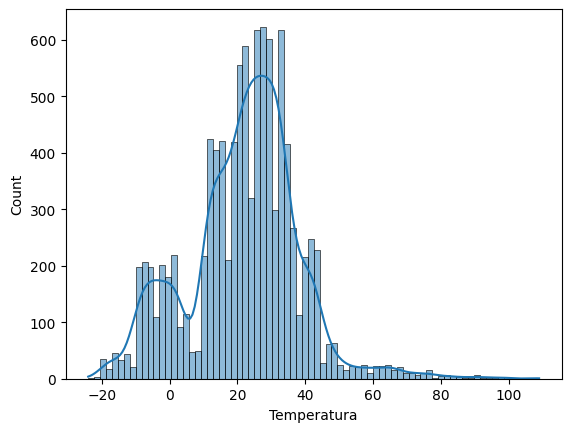

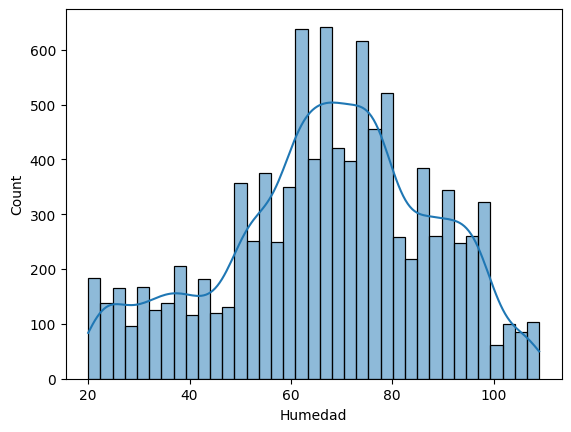

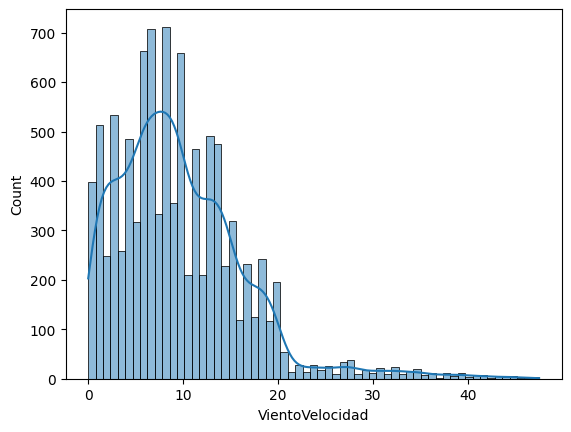

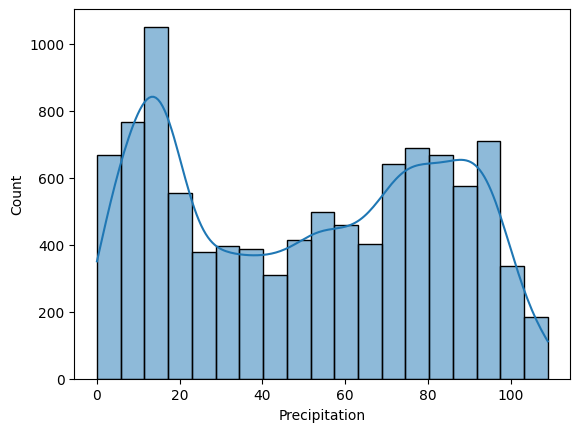

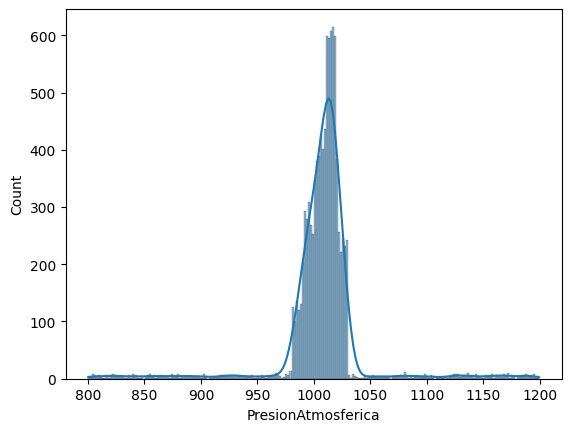

In [ ]:
for col in numeric_cols.columns:
  sns.histplot(x = col, kde = True, data = data)
  plt.show()


Observamos que las distribuciones de las variables explicativas son normales sesgadas o bimodales, por lo cual vamos a tratar los outliers.


Procedemos a eliminar los outliers por el rango intercuartílico.

In [ ]:
for col in numeric_cols.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]


Eliminamos todos los registros que posean humedad por fuera del rango [0:100] ya que la humedad solo puede tomar esos valores.

In [ ]:
data = data[(0 <= data['Humedad']) & (data['Humedad'] <= 100)]
data = data.reset_index(drop=True)

Graficamos nuevamente los boxplot para visualizar outliers.


In [ ]:
# filtrar del data solo columnas numericas
#numeric_cols = data.select_dtypes(include=[np.number])
cols = data.columns.tolist()
numeric_cols = data[cols].select_dtypes(include=[np.number])

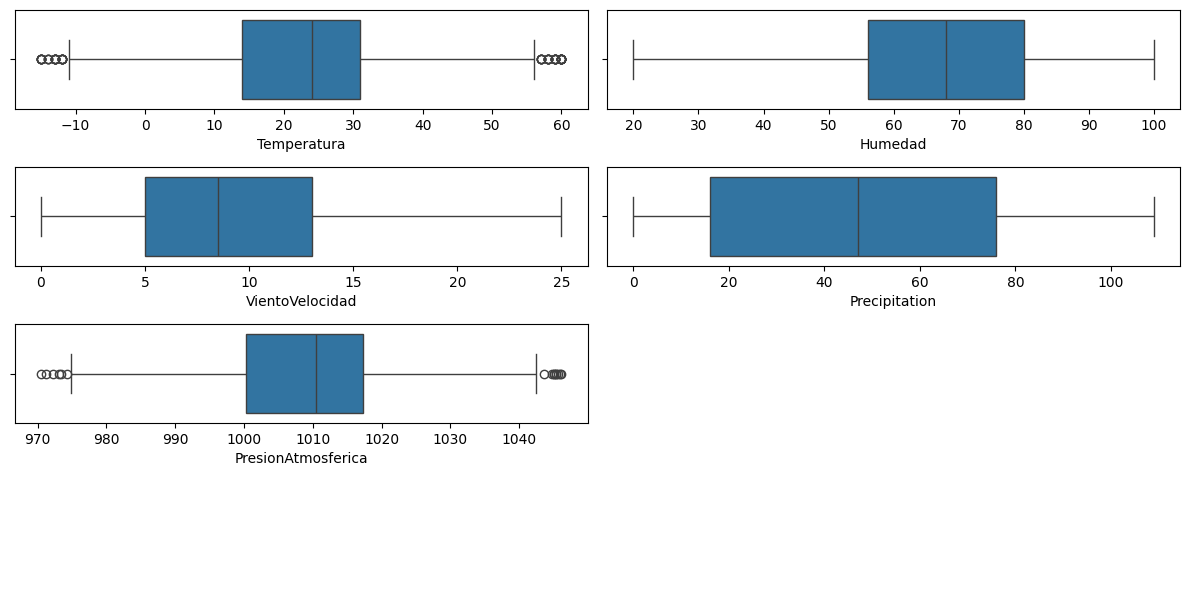

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 6))
k = 0
#Obtenemos el nombre de las columnsa
numeric_col_names = numeric_cols.columns.tolist()
for i in range(0,4):
    for j in range(0,2):
      if k > len(numeric_col_names)-1:
        break
      else:
        # Seleccionar la columna correspondiente usando el nombre de la columna
        col_name = numeric_col_names[k]
        sns.boxplot(x=numeric_cols[col_name], ax=axes[i,j])
        # Incrementar el índice de la columna
        k += 1

axes[2,1].axis('off')
axes[3,1].axis('off')
axes[3,0].axis('off')
plt.tight_layout()
plt.show()

Todavía registra algunos valores extremos en PresionAtmosferica y Temperatura, los mismos parecen valores muy poco probables, procedemos a eliminarlos.

In [ ]:
for col in numeric_cols.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

Corroboramos nuevamente los boxplot.

In [ ]:
# filtrar del data solo columnas numericas
#numeric_cols = data.select_dtypes(include=[np.number])
cols = data.columns.tolist()
numeric_cols = data[cols].select_dtypes(include=[np.number])

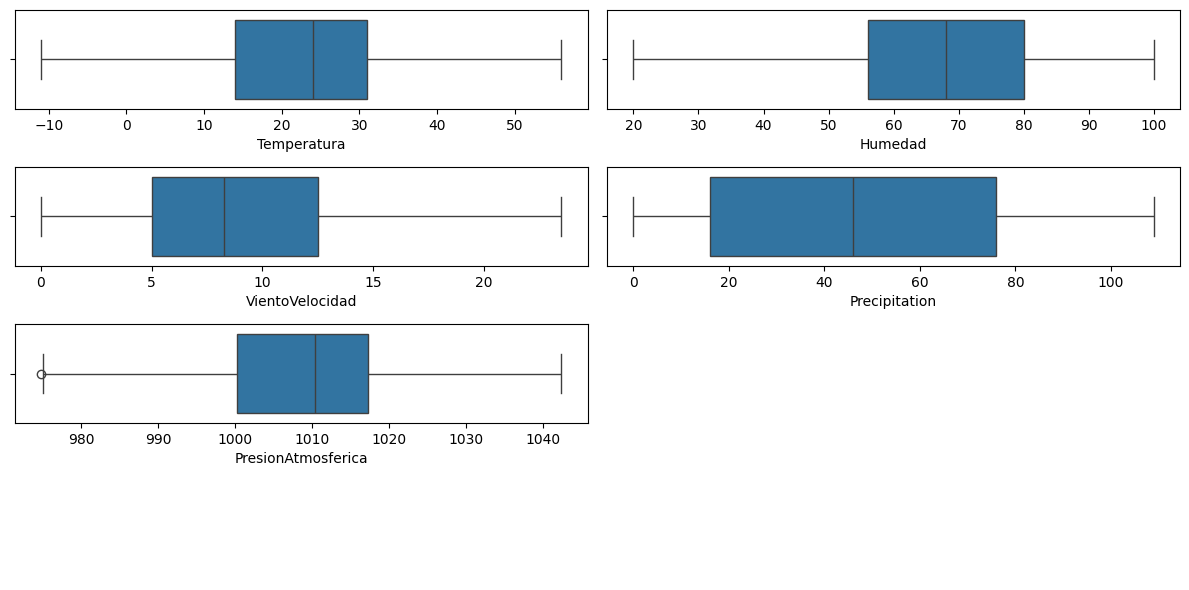

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 6))
k = 0
# Get the list of column names
numeric_col_names = numeric_cols.columns.tolist()
for i in range(0,4):
    for j in range(0,2):
      if k > len(numeric_col_names)-1:
        break
      else:
        # Seleccionar la columna correspondiente usando el nombre de la columna
        col_name = numeric_col_names[k]
        sns.boxplot(x=numeric_cols[col_name], ax=axes[i,j])
        # Incrementar el índice de la columna
        k += 1

axes[2,1].axis('off')
axes[3,1].axis('off')
axes[3,0].axis('off')
plt.tight_layout()
plt.show()

# Division Train Test

In [ ]:
X = data.drop(['Estacion'], axis = 1)
y = data['Estacion']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Analizamos el balance de la variable target.

<Axes: >

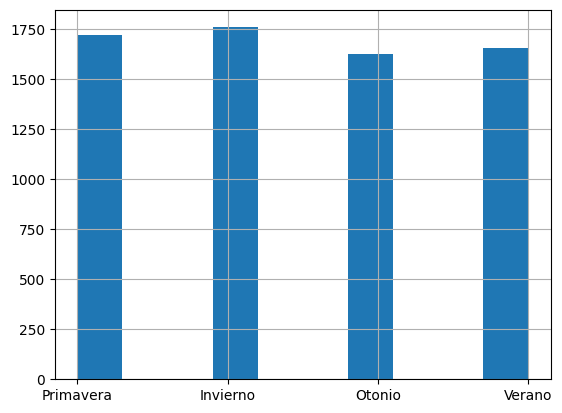

In [ ]:
y_train.hist()

Observamos que las clases están balanceadas por lo que no es necesario realizar ningún tratamiento en cuanto a balanceo de clases.

# Codificación y Estadarización

Por medio de un preprocesador estadarizamos las variables númericas con StandarScaler y codificamos con OneHotEncoder las variables categóricas, dado que estas últimas no presentan ordinalidad.

In [ ]:
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'), categorical_features)],
    remainder='drop'
)

In [ ]:
preprocessor.fit(X_train)
X_train_preprocessed = preprocessor.transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)


Visualizamos las variables luego del codificado y escalado.

In [ ]:
feature_names = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
X_train_preprocessed = pd.DataFrame(X_train_preprocessed, columns=feature_names)
X_test_preprocessed = pd.DataFrame(X_test_preprocessed, columns=feature_names)
X_test_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Temperatura            1692 non-null   float64
 1   Humedad                1692 non-null   float64
 2   VientoVelocidad        1692 non-null   float64
 3   Precipitation          1692 non-null   float64
 4   PresionAtmosferica     1692 non-null   float64
 5   Localizacion_Llanura   1692 non-null   float64
 6   Localizacion_Montania  1692 non-null   float64
 7   TipoClima_Nevado       1692 non-null   float64
 8   TipoClima_Nublado      1692 non-null   float64
 9   TipoClima_Soleado      1692 non-null   float64
dtypes: float64(10)
memory usage: 132.3 KB


In [ ]:
X_train_preprocessed.head()

,Temperatura,Humedad,VientoVelocidad,Precipitation,PresionAtmosferica,Localizacion_Llanura,Localizacion_Montania,TipoClima_Nevado,TipoClima_Nublado,TipoClima_Soleado
0,-0.110419,0.114491,2.009657,1.040313,-0.921741,0.0,0.0,0.0,0.0,0.0
1,-0.036066,-0.043128,0.029888,-0.189804,-0.227830,0.0,0.0,0.0,1.0,0.0
2,-0.259124,0.639890,-0.158662,-0.473677,-0.094095,0.0,1.0,0.0,1.0,0.0
3,0.781811,0.429731,0.501261,1.166479,-1.216969,1.0,0.0,0.0,0.0,0.0
4,0.261344,-0.358368,1.915382,0.441026,0.931211,0.0,1.0,0.0,0.0,0.0


# Comparación de Modelos de Clasificación y Optimización de Hiperparámetros

Desarrollaremos y compararemos distintos modelos de clasificación supervisada: Support Vector Machine (SVM) con kernel lineal, SVM con kernel gaussiano (RBF) y Random Forest.
Para cada modelo realizaremos una búsqueda de hiperparámetros utilizando Optuna, tomando un único fold de desarrollo como conjunto de validación.
Posteriormente, entrenaremos el modelo final con el conjunto de entrenamiento completo y evaluaremos su desempeño mediante validación cruzada estratificada de 5 folds utilizando como métricas de evalucación la exactitud, precisión, exhaustividad y F1-score.

In [ ]:
# División 5 fold
cv_dev = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(cv_dev.split(X_train_preprocessed, y_train))
#Primer fold para validación de desarrollo
X_dev_train, y_dev_train = X_train_preprocessed.iloc[folds[0][0]], y_train.iloc[folds[0][0]]# selecciona los datos que no están en el primer fold (75% restantes), para entrenar
X_dev_valid, y_dev_valid = X_train_preprocessed.iloc[folds[0][1]], y_train.iloc[folds[0][1]]# selecciona los datos del primer fold (25%), para validar

## SMV con Kernel Lineal


Procedemos a construir un modelo de clasificación SVM con kernel lineal. Para determinar su hiperparámetro, utilizamos Optuna como herramienta de optimización. El parámetro a ajustar es C (costo), que controla la penalización por errores de clasificación.

Valores bajos de C permiten una mayor tolerancia a errores, favoreciendo un modelo más generalizado (con tendencia al underfitting), mientras que valores altos penalizan más los errores, lo que puede llevar a un modelo más ajustado a los datos de entrenamiento (con riesgo de overfitting). Exploramos los siguientes valores: 0.1, 1, 10, 100 y 200.

In [ ]:
# Optimización de hiperparámetro C usando solo un fold
def objective(trial):
    C = trial.suggest_categorical("C", [0.001,0.1, 1, 10, 100, 200])
    svm = LinearSVC(C=C, max_iter=10000, random_state=42)
    svm.fit(X_dev_train, y_dev_train)
    return svm.score(X_dev_valid, y_dev_valid)  # Accuracy en validación de desarrollo

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

best_C = study.best_params['C']
print(f"\nMejor parámetro C encontrado: {best_C}")

#Métricas
scoring = {
    "exactitud":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, average="macro", zero_division=0),
    "exhaustividad":    make_scorer(recall_score,    average="macro", zero_division=0),
    "f1":        make_scorer(f1_score,        average="macro", zero_division=0),
}



# Entrenamiento del modelo final con todo el set de entrenamiento
svm_final = LinearSVC(C=best_C, max_iter=10000, random_state=42)
svm_final.fit(X_train_preprocessed, y_train)

# Evaluación final con cross-validation (5 folds)
cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = cross_validate(
    estimator   = svm_final,
    X           = X_train_preprocessed,
    y           = y_train,
    cv          = cv_final,
    scoring     = scoring,
    return_train_score = True      # para comparar train vs val
)

#  Resumen de resultados
for metric in scoring.keys():
    train_scores_svm = results[f"train_{metric}"]
    val_scores_svm   = results[f"test_{metric}"]
    print(f"{metric.capitalize():9s} | "
          f"Train: {train_scores_svm.mean():.3f} ± {train_scores_svm.std():.3f} | "
          f"Val: {val_scores_svm.mean():.3f} ± {val_scores_svm.std():.3f}")



[I 2025-06-18 14:03:35,100] A new study created in memory with name: no-name-14518588-f87b-4ca2-bdd0-7d6475f33df8
[I 2025-06-18 14:03:35,135] Trial 0 finished with value: 0.3995568685376662 and parameters: {'C': 1}. Best is trial 0 with value: 0.3995568685376662.
[I 2025-06-18 14:03:35,174] Trial 1 finished with value: 0.3995568685376662 and parameters: {'C': 100}. Best is trial 0 with value: 0.3995568685376662.
[I 2025-06-18 14:03:35,201] Trial 2 finished with value: 0.3803545051698671 and parameters: {'C': 0.001}. Best is trial 0 with value: 0.3995568685376662.
[I 2025-06-18 14:03:35,236] Trial 3 finished with value: 0.3995568685376662 and parameters: {'C': 100}. Best is trial 0 with value: 0.3995568685376662.
[I 2025-06-18 14:03:35,269] Trial 4 finished with value: 0.3995568685376662 and parameters: {'C': 200}. Best is trial 0 with value: 0.3995568685376662.
[I 2025-06-18 14:03:35,303] Trial 5 finished with value: 0.3995568685376662 and parameters: {'C': 200}. Best is trial 0 with v


Mejor parámetro C encontrado: 1
Exactitud | Train: 0.407 ± 0.004 | Val: 0.387 ± 0.007
Precision | Train: 0.470 ± 0.005 | Val: 0.447 ± 0.006
Exhaustividad | Train: 0.401 ± 0.004 | Val: 0.381 ± 0.006
F1        | Train: 0.406 ± 0.007 | Val: 0.386 ± 0.004


El valor óptimo de C obtenido es 1. Las métricas evaluadas sobre los conjuntos de entrenamiento y validación presentan valores similares, lo cual indica que el modelo no esta aprendiendo bien a distinguir las clases. Además, las métricas son bajas lo que sugiere que el modelo puede mejorar su capacidad predictiva.

Realizamos la predicción para el conjunto de test y evaluamos métricas.


In [ ]:
# Predecir sobre conjunto test
y_pred_svm = svm_final.predict(X_test_preprocessed)

# Calcular métricas
precision_lineal = precision_score(y_test, y_pred_svm, average='macro')  # ponderado para multiclase
recall_lineal  = recall_score(y_test, y_pred_svm, average='macro')
accuracy_lineal  = accuracy_score(y_test, y_pred_svm, normalize=True)
f1_lineal = f1_score(y_test, y_pred_svm, average='macro')

print(f"Exactitud: {accuracy_lineal :.4f}")
print(f"Precisión: {precision_lineal :.4f}")
print(f"Exhaustividad: {recall_lineal :.4f}")
print(f"F1: {f1_lineal :.4f}")

Exactitud: 0.3735
Precisión: 0.4506
Exhaustividad: 0.3739
F1: 0.3718


Las métricas obtenidas son similares a las de validación y a las de train.

Graficamos la Matriz de Confusión.



In [ ]:
for i, clase in enumerate(np.unique(y_test)):
    print(f"{i} - {clase}")

0 - Invierno
1 - Otonio
2 - Primavera
3 - Verano


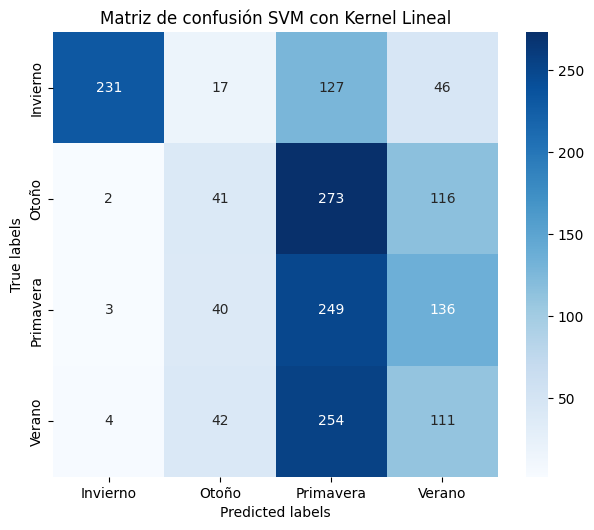

In [ ]:
class_labels = ['Invierno', 'Otoño', 'Primavera', 'Verano']
plot_multiple_conf_matrices(
    y_real_list=[y_test],
    y_pred_list=[y_pred_svm],
    titles=['Matriz de confusión SVM con Kernel Lineal'],
    class_names=class_labels)

En la matriz de confusión observamos que la clase 0 (invierno) presenta la mayor precisión, ya que la mayoría de los casos predichos como invierno efectivamente pertenecen a esa clase (231 verdaderos positivos frente a pocos falsos positivos).

Asimismo, invierno también muestra la mejor exhaustividad (recall): de todos los ejemplos reales de invierno, una gran proporción fue correctamente clasificada.

Por otro lado, la clase 3 (verano) es la que presenta peor exhaustividad, dado que una parte considerable de sus casos reales se clasificaron erróneamente como otras estaciones (especialmente como primavera y otoño).

In [ ]:
report_test = classification_report(y_test, y_pred_svm, output_dict=True, zero_division=0)
df_report_test = pd.DataFrame(report_test).transpose().round(2)

print("\n=== Reporte de SVM Kernel Lineal en Test ===")
display(df_report_test[['precision', 'recall', 'f1-score', 'support']])


=== Reporte de SVM Kernel Lineal en Test ===


,precision,recall,f1-score,support
Invierno,0.96,0.55,0.70,421.00
Otonio,0.29,0.09,0.14,432.00
Primavera,0.28,0.58,0.37,428.00
Verano,0.27,0.27,0.27,411.00
accuracy,0.37,0.37,0.37,0.37
macro avg,0.45,0.37,0.37,1692.00
weighted avg,0.45,0.37,0.37,1692.00


## SMV con Kernel Gaussiano

Procedemos a construir un modelo de clasificación SVM con kernel gaussiano (RBF), que permite capturar relaciones no lineales.
Para determinar sus hiperparámetros, utilizamos Optuna como herramienta de optimización. Los parámetros a ajustar son:

* C (costo): controla la penalización por errores de clasificación.

* gamma: define la influencia de cada punto en la frontera de decisión del modelo.

Exploramos los siguientes valores:

C: 0.1, 1, 10, 100 y 200

gamma: 0.01, 0.1, 1, 10 y 100

Valores bajos de C permiten un mayor margen para errores, favoreciendo un modelo más generalizado (underfitting), mientras que valores altos tienden a sobreajustar los datos (overfitting).
Respecto a gamma, valores bajos generan funciones de decisión más suaves y amplias(underfitting) , mientras que valores altos pueden llevar a decisiones más precisas y locales (overfitting).

In [ ]:
# Optimización de hiperparámetros C y gamma usando solo un fold
def objective(trial):
    C = trial.suggest_categorical("C", [0.001, 0.1, 1, 10, 100, 200])
    gamma = trial.suggest_categorical("gamma", [0.01, 0.1, 1, 10, 100])
    svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
    svm.fit(X_dev_train, y_dev_train)
    return svm.score(X_dev_valid, y_dev_valid)  # Accuracy en validación de desarrollo

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

best_params = study.best_params
print(f"\nMejores hiperparámetros encontrados: {best_params}")

# Métricas
scoring = {
    "exactitud":      make_scorer(accuracy_score),
    "precision":      make_scorer(precision_score, average="macro", zero_division=0),
    "exhaustividad":  make_scorer(recall_score,    average="macro", zero_division=0),
    "f1":             make_scorer(f1_score,        average="macro", zero_division=0),
}

# Entrenamiento del modelo final con todo el set de entrenamiento
svm_rbf_final = SVC(kernel='rbf', C=best_params["C"], gamma=best_params["gamma"], random_state=42)
svm_rbf_final.fit(X_train_preprocessed, y_train)

# Evaluación final con validación cruzada (5 folds)
cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = cross_validate(
    estimator           = svm_rbf_final,
    X                   = X_train_preprocessed,
    y                   = y_train,
    cv                  = cv_final,
    scoring             = scoring,
    return_train_score  = True
)

# Resumen de resultados
for metric in scoring.keys():
    train_scores_rbf = results[f"train_{metric}"]
    val_scores_rbf   = results[f"test_{metric}"]
    print(f"{metric.capitalize():15s} | "
          f"Train: {train_scores_rbf.mean():.3f} ± {train_scores_rbf.std():.3f} | "
          f"Val: {val_scores_rbf.mean():.3f} ± {val_scores_rbf.std():.3f}")

[I 2025-06-18 14:03:37,753] A new study created in memory with name: no-name-09c80ce2-953f-41a0-817c-7067256d4f1e
[I 2025-06-18 14:03:43,099] Trial 0 finished with value: 0.3810930576070901 and parameters: {'C': 200, 'gamma': 1}. Best is trial 0 with value: 0.3810930576070901.
[I 2025-06-18 14:03:44,456] Trial 1 finished with value: 0.41063515509601184 and parameters: {'C': 1, 'gamma': 0.01}. Best is trial 1 with value: 0.41063515509601184.
[I 2025-06-18 14:03:47,501] Trial 2 finished with value: 0.4069423929098966 and parameters: {'C': 100, 'gamma': 0.1}. Best is trial 1 with value: 0.41063515509601184.
[I 2025-06-18 14:03:51,922] Trial 3 finished with value: 0.37370753323485967 and parameters: {'C': 100, 'gamma': 1}. Best is trial 1 with value: 0.41063515509601184.
[I 2025-06-18 14:03:53,621] Trial 4 finished with value: 0.25997045790251105 and parameters: {'C': 0.001, 'gamma': 0.1}. Best is trial 1 with value: 0.41063515509601184.
[I 2025-06-18 14:03:56,467] Trial 5 finished with va


Mejores hiperparámetros encontrados: {'C': 1, 'gamma': 0.01}
Exactitud       | Train: 0.401 ± 0.002 | Val: 0.399 ± 0.007
Precision       | Train: 0.367 ± 0.069 | Val: 0.369 ± 0.049
Exhaustividad   | Train: 0.391 ± 0.002 | Val: 0.389 ± 0.007
F1              | Train: 0.301 ± 0.015 | Val: 0.301 ± 0.018


Los hiperparámetros óptimos encontrados para el modelo SVM con kernel gaussiano fueron: C = 1 y gamma = 0.1.
Las métricas fueron consistentes entre entrenamiento y validación, indicando baja varianza, pero a costa de un sesgo alto ya que poseen valores bajos y parecidos.

En términos generales, las métricas obtenidas son comparables a las del modelo SVM con kernel lineal, aunque el F1-score resultó ligeramente inferior, lo que indica un menor equilibrio entre precisión y recall para las distintas clases.



Realizamos la predicción para el conjunto de test y evaluamos métricas.

In [ ]:
# Predecir sobre conjunto test con el modelo RBF final
y_pred_rbf = svm_rbf_final.predict(X_test_preprocessed)

# Calcular métricas
precision_rbf = precision_score(y_test, y_pred_rbf, average='macro')
recall_rbf    = recall_score(y_test, y_pred_rbf, average='macro')
accuracy_rbf  = accuracy_score(y_test, y_pred_rbf, normalize=True)
f1_rbf        = f1_score(y_test, y_pred_rbf, average='macro')

# Imprimir resultados
print(f"Exactitud:        {accuracy_rbf :.4f}")
print(f"Precisión:        {precision_rbf :.4f}")
print(f"Exhaustividad:    {recall_rbf :.4f}")
print(f"F1:               {f1_rbf :.4f}")


Exactitud:        0.3877
Precisión:        0.3138
Exhaustividad:    0.3854
F1:               0.2878


Graficamos la Matriz de Confusión.

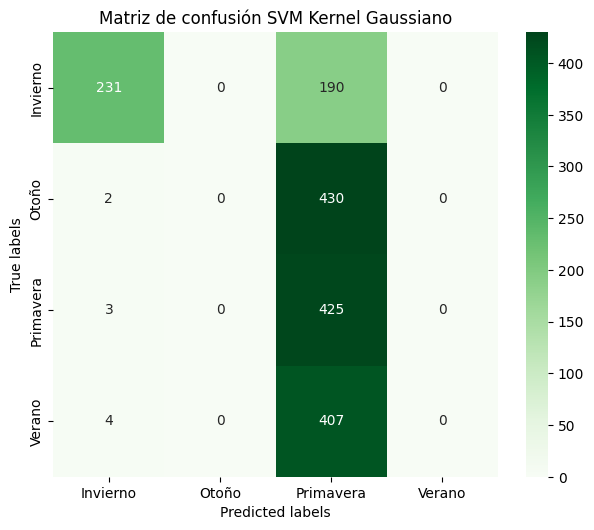

In [ ]:
plot_multiple_conf_matrices(
    y_real_list=[y_test],
    y_pred_list=[y_pred_rbf],
    titles=['Matriz de confusión SVM Kernel Gaussiano'],
    class_names=class_labels)

En esta matriz de confusión observamos un sesgo del modelo hacia la clase Primavera, que absorbe una gran cantidad de instancias de otras clases, generando una precisión muy baja para dicha clase y un recall muy bajo para las clases Otoño y Verano.

Si bien la *clase Otoño* mantiene una clasificación precisa, las clases *Invierno* y *Verano* muestran un alto nivel de confusión con la clase *Primavera*, afectando el equilibrio general del modelo.
Esto justifica la baja puntuación del F1-score, que refleja un desequilibrio entre precisión y exhaustividad especialmente en las clases menos favorecidas.



In [ ]:
report_test = classification_report(y_test, y_pred_rbf, output_dict=True, zero_division=0)
df_report_test = pd.DataFrame(report_test).transpose().round(2)

print("\n=== Reporte de SVM Kernel Gaussiano en Test ===")
display(df_report_test[['precision', 'recall', 'f1-score', 'support']])


=== Reporte de SVM Kernel Gaussiano en Test ===


,precision,recall,f1-score,support
Invierno,0.96,0.55,0.70,421.00
Otonio,0.00,0.00,0.00,432.00
Primavera,0.29,0.99,0.45,428.00
Verano,0.00,0.00,0.00,411.00
accuracy,0.39,0.39,0.39,0.39
macro avg,0.31,0.39,0.29,1692.00
weighted avg,0.31,0.39,0.29,1692.00


## Random Forest

Construimos un modelo de clasificación utilizando arboles de decision.

Random Forest es especialmente robusto frente a outliers y desequilibrios, y permite modelar relaciones no lineales entre variables.

Para ajustar sus hiperparámetros, utilizamos Optuna como herramienta de optimización.

Los parámetros seleccionados para búsqueda fueron:

*   **n_estimators:** número de árboles en el bosque. [50, 100, 150, 200, 250, 300]
*   **max_depth:** profundidad máxima permitida de cada árbol. [de 3 a 20]

Valores bajos de **n_estimators** pueden llevar a un modelo inestable (underfitting), mientras que un número muy alto aumenta el tiempo de cómputo sin mejorar necesariamente el rendimiento.

Un **max_depth** bajo puede generar árboles poco expresivos (underfitting), mientras que una profundidad muy grande puede llevar a árboles sobreajustados (overfitting).





In [ ]:
def objective(trial):
  """Función objetivo para optimizar la profundidad maxima y cantidad de arboles con validación cruzada k=5"""
  n_estimators = trial.suggest_int('n_estimators', 50, 300, step=30)
  max_depth = trial.suggest_int('max_depth', 3, 20)
  rf = RandomForestClassifier(n_estimators=n_estimators,max_depth=max_depth,random_state=42)
  rf.fit(X_dev_train, y_dev_train)
  return rf.score(X_dev_valid, y_dev_valid)

# Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Mejor combinación de hiperparámetros
best_params = study.best_params
print("\nMejores hiperparámetros encontrados:")
for param, value in best_params.items():
    print(f"{param}: {value}")

# Definición de métricas
scoring = {
    "exactitud":  make_scorer(accuracy_score),
    "precision":  make_scorer(precision_score, average="macro", zero_division=0),
    "exhaustividad": make_scorer(recall_score, average="macro", zero_division=0),
    "f1":         make_scorer(f1_score, average="macro", zero_division=0),
}

# Modelo final con los mejores hiperparámetros
rf_final = RandomForestClassifier(
    **best_params,
    random_state=42
)
rf_final.fit(X_train_preprocessed, y_train)

# Evaluación con cross-validation
cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = cross_validate(
    estimator=rf_final,
    X=X_train_preprocessed,
    y=y_train,
    cv=cv_final,
    scoring=scoring,
    return_train_score=True
)

for metric in scoring.keys():
    train_scores_rf = results[f"train_{metric}"]
    val_scores_rf   = results[f"test_{metric}"]
    print(f"{metric.capitalize():9s} | "
          f"Train: {train_scores_rf.mean():.3f} ± {train_scores_rf.std():.3f} | "
          f"Val: {val_scores_rf.mean():.3f} ± {val_scores_rf.std():.3f}")


[I 2025-06-18 14:39:45,819] A new study created in memory with name: no-name-072c4c02-2fe9-4c69-835c-3583e91bd8fd
[I 2025-06-18 14:39:47,452] Trial 0 finished with value: 0.3766617429837518 and parameters: {'n_estimators': 230, 'max_depth': 16}. Best is trial 0 with value: 0.3766617429837518.
[I 2025-06-18 14:39:48,543] Trial 1 finished with value: 0.37961595273264404 and parameters: {'n_estimators': 140, 'max_depth': 19}. Best is trial 1 with value: 0.37961595273264404.
[I 2025-06-18 14:39:49,074] Trial 2 finished with value: 0.3803545051698671 and parameters: {'n_estimators': 80, 'max_depth': 14}. Best is trial 2 with value: 0.3803545051698671.
[I 2025-06-18 14:39:50,429] Trial 3 finished with value: 0.3700147710487445 and parameters: {'n_estimators': 200, 'max_depth': 15}. Best is trial 2 with value: 0.3803545051698671.
[I 2025-06-18 14:39:52,999] Trial 4 finished with value: 0.37518463810930575 and parameters: {'n_estimators': 290, 'max_depth': 20}. Best is trial 2 with value: 0.38


Mejores hiperparámetros encontrados:
n_estimators: 140
max_depth: 4
Exactitud | Train: 0.456 ± 0.002 | Val: 0.388 ± 0.012
Precision | Train: 0.572 ± 0.016 | Val: 0.453 ± 0.014
Exhaustividad | Train: 0.449 ± 0.002 | Val: 0.381 ± 0.012
F1        | Train: 0.433 ± 0.009 | Val: 0.361 ± 0.014


Los hiperparámetros óptimos encontrados para el modelo Random Forest fueron: n_estimators = 50 y max_depth = 4.
En la validación cruzada, las métricas en el conjunto de entrenamiento resultaron ligeramente superiores a las del conjunto de validación, lo que podría indicar una leve tendencia al sobreajuste, aunque dentro de márgenes razonables considerando que max_depth es bajo.
Aun así, todas las métricas (exactitud, precisión, exhaustividad y F1-score) muestran una mejora respecto a los modelos SVM.

Realizamos la predicción para el conjunto de test y evaluamos métricas.

In [ ]:
# Predecir sobre conjunto test con el modelo RandomForest final
y_pred_rf = rf_final.predict(X_test_preprocessed)

# Calcular métricas
precision_rf = precision_score(y_test, y_pred_rf, average='macro')
recall_rf    = recall_score(y_test, y_pred_rf, average='macro')
accuracy_rf  = accuracy_score(y_test, y_pred_rf, normalize=True)
f1_rf        = f1_score(y_test, y_pred_rf, average='macro')

# Imprimir resultados
print(f"Exactitud:        {accuracy_rf :.4f}")
print(f"Precisión:        {precision_rf :.4f}")
print(f"Exhaustividad:    {recall_rf :.4f}")
print(f"F1:               {f1_rf :.4f}")


Exactitud:        0.3842
Precisión:        0.4892
Exhaustividad:    0.3833
F1:               0.3476


Los resultados son similares a los de validación.

Graficamos el Árbol de decisión de Random Forest entrenado con hiperparámetros óptimos (max_depth = 4).

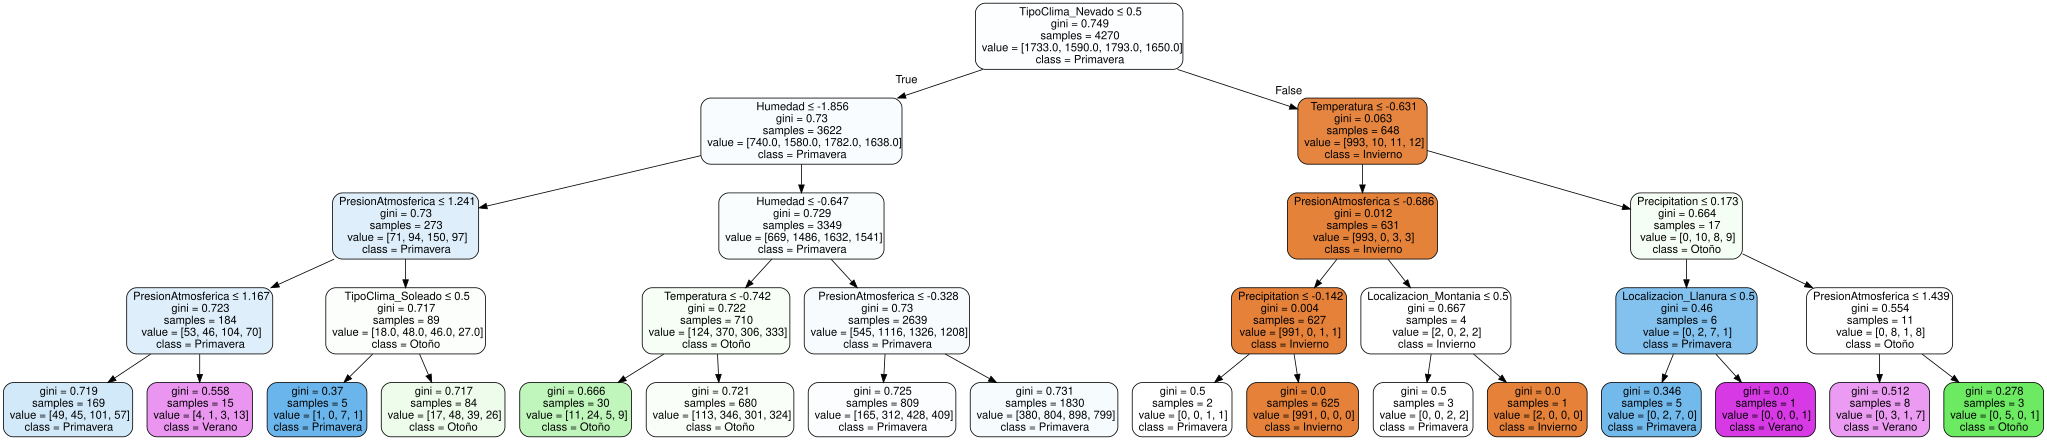

In [ ]:
# Exportar el árbol entrenado sobre el set de validación de desarrollo (usado por Optuna)
export_graphviz(
    rf_final.estimators_[0],                 # Árbol único del bosque entrenado con Optuna
    out_file="tree_rf_dev.dot",
    feature_names=X_train_preprocessed.columns,
    class_names=['Invierno', 'Otoño', 'Primavera', 'Verano'],
    filled=True,
    rounded=True,
    special_characters=True,
    rotate = False
)

# Leer y mostrar el árbol con Graphviz
Source.from_file("tree_rf_dev.dot")


En cada nodo podemos ver:

*   Condicion de division
*   Indice de gini
*   Cantidad de muestras en ese nodo
*   Distribucion de las clases
*   Clase mayoritaria en el nodo

En lineas generales notamos que donde hay una clases como Otoño o Primavera las divisiones son menos efectivas, es decir, poseen menos pureza (gini mas alto).
La mayoria de las predicciones se inclinan a Primavera y mantienen el gini alto por lo que nos da indicios de que el modelo la confunde con otros casos



Graficamos la Matriz de Confusión.

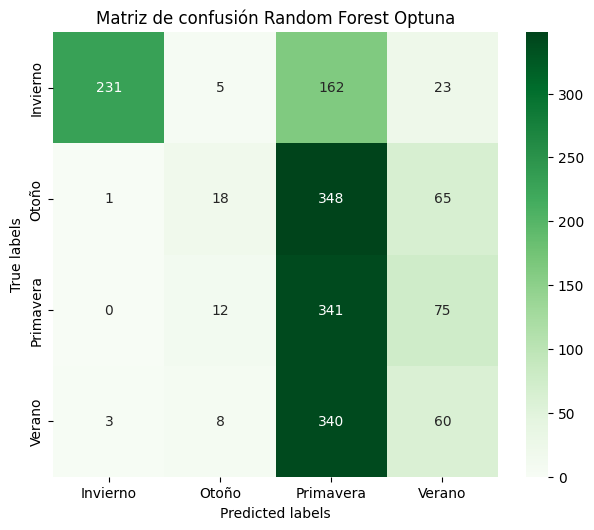

In [ ]:
plot_multiple_conf_matrices(
    y_real_list=[y_test],
    y_pred_list=[y_pred_rf],
    titles=['Matriz de confusión Random Forest Optuna'],
    class_names=class_labels)

In [ ]:
# Reporte detallado por clase en test
report_test = classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)
df_report_test = pd.DataFrame(report_test).transpose().round(2)

print("\n=== Reporte de RandomForest en Test ===")
display(df_report_test[['precision', 'recall', 'f1-score', 'support']])



=== Reporte de RandomForest en Test ===


,precision,recall,f1-score,support
Invierno,0.98,0.55,0.70,421.00
Otonio,0.42,0.04,0.08,432.00
Primavera,0.29,0.80,0.42,428.00
Verano,0.27,0.15,0.19,411.00
accuracy,0.38,0.38,0.38,0.38
macro avg,0.49,0.38,0.35,1692.00
weighted avg,0.49,0.38,0.35,1692.00


Podemos observar en la matriz de confusión que la clase *Invierno* presenta dificultades de clasificación, con un número considerable de instancias mal clasificadas como '*clase Primavera*', lo que refleja una baja precisión para la clase *Primavera* y una baja exhaustividad (recall) para la clase *Invierno*.
A su vez, la clase Primavera acumula una gran cantidad de falsos positivos, tal como se observó también en los modelos basados en SVM, evidenciando un patrón de sesgo del modelo hacia esta clase.

# Conclusión

In [ ]:
# Crear la tabla con los resultados de test
df_comparacion_test = pd.DataFrame({
    'Modelo': ['SVM Lineal', 'SVM RBF', 'Random Forest'],
    'Accuracy': [accuracy_lineal, accuracy_rbf, accuracy_rf],
    'Precision': [precision_lineal, precision_rbf, precision_rf],
    'Recall': [recall_lineal, recall_rbf, recall_rf],
    'F1-score': [f1_lineal, f1_rbf, f1_rf]
})

# Redondear a 4 decimales para mejor presentación
df_comparacion_test = df_comparacion_test.round(4)

# Mostrar tabla
print("\n=== Comparación de métricas en conjunto de TEST ===")
display(df_comparacion_test)



=== Comparación de métricas en conjunto de TEST ===


,Modelo,Accuracy,Precision,Recall,F1-score
0,SVM Lineal,0.3735,0.4506,0.3739,0.3718
1,SVM RBF,0.3877,0.3138,0.3854,0.2878
2,Random Forest,0.3842,0.4892,0.3833,0.3476


Se entrenaron tres modelos de clasificación supervisada: SVM con kernel lineal, SVM con kernel gaussiano (RBF) y Random Forest. Para cada uno se realizó una optimización de hiperparámetros utilizando Optuna, con validación sobre un único fold de desarrollo. Luego, se entrenó el modelo final con los mejores hiperparámetros y se evaluó su rendimiento con validación cruzada estratificada de 5 folds, utilizando como métricas exactitud, precisión, exhaustividad y F1-score,  además de un análisis mediante la matriz de confusión.

El modelo SVM con kernel lineal mostró un rendimiento moderado pero más equilibrado entre clases, con métricas similares entre entrenamiento y validación. En cambio, el modelo SVM con kernel RBF presentó una caída en el F1-score y mostró un sesgo hacia una clase dominante, disminuyendo la capacidad para clasificar correctamente el resto de las clases.

Por su parte, el modelo de Random Forest obtuvo mejores métricas en general, aunque con una diferencia más marcada entre entrenamiento y validación, lo que sugiere un ligero sobreajuste. Sin embargo, mostró un mejor desempeño en la mayoría de las clases, aunque aún con confusiones en una cantidad considerable de etiquetas.

Considerando su mayor distribución con respecto a las clases predichas y su mejora en las métricas, creemos que el modelo Random Forest fue el que mejor se adaptó al conjunto de datos evaluado.